## Análisis y Predicción de Precios de Autos (Core)
#####  Aplicar los conceptos de regresión lineal para resolver un problema práctico utilizando Python.

##### Objetivo: Aplicar técnicas de regresión lineal, KNN y árboles de decisión para predecir precios de autos utilizando un dataset de Kaggle. Realizar un Análisis Exploratorio de Datos (EDA) completo y comparar el rendimiento de los modelos mediante benchmarking.

#### Parte 1: Análisis Exploratorio de Datos (EDA)

##### 1. Carga y Exploración de Datos:

##### 1.1- Cargar el dataset y revisar la estructura básica.


In [1497]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV , cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# Cargar el archivo CSV
df = pd.read_csv('./data/Automobile_data.csv')
# df = pd.read_csv('./data/Automobile_data.csv',usecols=['Price', 'SqFt', 'Bedrooms', 'Bathrooms'])
# df = pd.read_csv('./data/Automobile_data.csv').drop(columns=['Home', 'Offers', 'Brick', 'Neighborhood']).dropna()


# mostrar los primeros 10 registros
display("primeros 10 registros : ",df.head(10))

# los ultimos 5 registros
display("ultimos 5 registros : ",df.tail())

# informacion general del dataframe:
print("informacion general del dataframe : ",df.info())

# informacion estadisticas del dataframe :
display("informacion estadisticas del dataframe : ")
df.describe()


'primeros 10 registros : '

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450
5,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,17710
7,1,?,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.4,8.3,140,5500,17,20,23875
9,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.4,7.0,160,5500,16,22,?


'ultimos 5 registros : '

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.4,23.0,106,4800,26,27,22470
204,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,19,25,22625


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

'informacion estadisticas del dataframe : '

,symboling,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,city-mpg,highway-mpg
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,10.142537,25.219512,30.751220
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,3.972040,6.542142,6.886443
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,8.600000,19.000000,25.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,24.000000,30.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,9.400000,30.000000,34.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000


##### 1.2-  Descripción de las variables y su distribución.



In [1498]:
df.describe().round(2)

print(" - Identificar y solucionar cualquier inconsistencia en los valores categóricos (ejemplo: cat, Cat, cats).")

for col in df.columns:
    valores_unicos = df[col].unique()
    print(f"• {col:20} -> {len(valores_unicos)} únicos")
    print(f"  Lista de Valores :   {valores_unicos}\n")

# problemas encontrados en las columnas con valor nan y ?

# 1. Reemplazar los "?" por NaN (muy importante)
df.replace('?', pd.NA, inplace=True)

# Convertir columnas con "?" a numéricas (NaN)
for col in ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm', 'price']:
    df[col] = pd.to_numeric(df[col], errors='coerce')



diccionario = {
    'symboling': 'int64',
    'normalized-losses': 'float64',
    'make': 'str',
    'fuel-type': 'str',
    'aspiration': 'str',
    'num-of-doors': 'str',
    'body-style': 'str',
    'drive-wheels': 'str',
    'engine-location': 'str',
    'wheel-base': 'float64',
    'length': 'float64',
    'width': 'float64',
    'height': 'float64',
    'curb-weight': 'int64',
    'engine-type': 'str',
    'num-of-cylinders': 'str',
    'engine-size': 'int64',
    'fuel-system': 'str',
    'bore': 'float64',
    'stroke': 'float64',
    'compression-ratio': 'float64',
    'horsepower': 'float64',
    'peak-rpm': 'float64',
    'city-mpg': 'int64',
    'highway-mpg': 'int64',
    'price': 'float64'
}


# transformamos a los tipos correctos cada columna deacuerdo al diccionario de datos
df = df.astype(diccionario, errors='ignore')
print("verificacion de las columnas Transformadas deacuerdo al diccionario : \n",df.dtypes)


print(" Identificar y solucionar cualquier valor duplicado.\n")

    
if df.duplicated().sum() == 0 :
    print("no se encontraron valores duplicados en el dataframe.")
else:
    print("\nDuplicados totales  = ", df.duplicated().sum() , "; se realiza drop ")
    df = df.drop_duplicates()
    print("Duplicados totales despues del drop :", df.duplicated().sum())
    display(df)    




 - Identificar y solucionar cualquier inconsistencia en los valores categóricos (ejemplo: cat, Cat, cats).
• symboling            -> 6 únicos
  Lista de Valores :   [ 3  1  2  0 -1 -2]

• normalized-losses    -> 52 únicos
  Lista de Valores :   ['?' '164' '158' '192' '188' '121' '98' '81' '118' '148' '110' '145' '137'
 '101' '78' '106' '85' '107' '104' '113' '150' '129' '115' '93' '142'
 '161' '153' '125' '128' '122' '103' '168' '108' '194' '231' '119' '154'
 '74' '186' '83' '102' '89' '87' '77' '91' '134' '65' '197' '90' '94'
 '256' '95']

• make                 -> 22 únicos
  Lista de Valores :   ['alfa-romero' 'audi' 'bmw' 'chevrolet' 'dodge' 'honda' 'isuzu' 'jaguar'
 'mazda' 'mercedes-benz' 'mercury' 'mitsubishi' 'nissan' 'peugot'
 'plymouth' 'porsche' 'renault' 'saab' 'subaru' 'toyota' 'volkswagen'
 'volvo']

• fuel-type            -> 2 únicos
  Lista de Valores :   ['gas' 'diesel']

• aspiration           -> 2 únicos
  Lista de Valores :   ['std' 'turbo']

• num-of-doors         

##### 1.3-  Detección y tratamiento de valores nulos.


In [1499]:
# columnas numericas identificadas
columnas = ['wheel-base', 'length', 'width', 'height', 'curb-weight', 
                'engine-size', 'bore', 'stroke', 'compression-ratio', 
                'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']

# - Identificar y abordar cualquier valor duplicado.
print("Duplicados totales:", df.duplicated().sum())

        # verificar datos nulos en el dataframe
print("\nDatos nulos por columna : \n")
print(df.isnull().sum())

print("\nDatos nulos totales : ", df.isnull().sum().sum())
df.replace('?', 0, inplace=True)
df.replace(np.nan, 0, inplace=True)
# se encontraron datos nulos en el dataframe, se procede a eliminar filas con datos nulos.
# df = df.dropna()

# tranformo calumnas a numericas
for col in columnas:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# verifico que se eliminaron los datos del dataframe
for col in df.columns:
    valores_unicos = df[col].unique()
    print(f"• {col:20} -> {len(valores_unicos)} únicos")
    print(f"  Lista de Valores :   {valores_unicos}\n")

# verifico nulos denuevo
print("\nDatos nulos totales : ", df.isnull().sum().sum())    

display("dataframe limpio sin nulos : ", df)



Duplicados totales: 0

Datos nulos por columna : 

symboling             0
normalized-losses    41
make                  0
fuel-type             0
aspiration            0
num-of-doors          0
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 4
dtype: int64

Datos nulos totales :  57
• symboling            -> 6 únicos
  Lista de Valores :   [ 3  1  2  0 -1 -2]

• normalized-losses    -> 52 únicos
  Lista de Valores :   [  0. 164. 158. 192. 188. 121.  98.  81. 118. 148. 110. 145. 137. 101.
  78. 106.  85. 107. 104. 113. 150. 129. 115.  93. 142. 161. 153. 125.
 128.

'dataframe limpio sin nulos : '

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,0.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,0.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,0.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114.0,5400.0,23,28,16845.0
201,-1,95.0,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160.0,5300.0,19,25,19045.0
202,-1,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134.0,5500.0,18,23,21485.0
203,-1,95.0,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106.0,4800.0,26,27,22470.0


##### 1.4-  Identificación y tratamiento de outliers.


In [1500]:
columnas = ['wheel-base', 'length', 'width', 'height', 'curb-weight', 
                'engine-size', 'bore', 'stroke', 'compression-ratio', 
                'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']

# Deteccion de  outliers codigo basado en ejemplo de stackoverflow
# https://stackoverflow.com/questions/75938497/outlier-detection-of-time-series-data


def deteccion_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    limit_inf = Q1 - 1.5 * IQR
    limit_sup = Q3 + 1.5 * IQR
    outliers = df[(df[column] < limit_inf) | (df[column] > limit_sup)]
    return outliers, limit_inf, limit_sup

def remover_outliers(df_e, column):
    Q1 = df_e[column].quantile(0.25)
    Q3 = df_e[column].quantile(0.75)
    IQR = Q3 - Q1
    limit_inf = Q1 - 1.5 * IQR
    limit_sup = Q3 + 1.5 * IQR
    df_out = df_e[(df_e[column] >= limit_inf) & (df_e[column] <= limit_sup)]
    return df_out

def mostrar_correccion_outliers(df_lim, column, arr_outliers):
   # print("arr_outliers", arr_outliers[column])

    existe = any(arr== column for arr in arr_outliers)
    #print("existe : ", existe)
    if existe: 
        outliers = df_lim[(df_lim[column] < arr_outliers[column]['lower']) | (df_lim[column] > arr_outliers[column]['upper'])]
 #       print(f"outliers {df_lim[column]} " )
 #       display("mostrar outliers", outliers)
        count = len(outliers) # cuenta la cantidad de outliers encontrados en la columna
        print(f"{column:18} -> cantidad de outliers = {count:3} | limites : [{arr_outliers[column]['lower']:,.2f}, {arr_outliers[column]['upper']:,.2f}]")



print("deteccion de outlierns. \n ")

arr_outliers = {}

for col in columnas:
        outliers, lower, upper = deteccion_outliers(df, col)
        # Guardas los valores

        count = len(outliers) # cuenta la cantidad de outliers encontrados en la columna
        if count > 0:
            print(f"{col:18} -> cantidad de outliers = {count:3} | limites : [{lower:,.2f}, {upper:,.2f}]")
            nombre_outlier = col
            arr_outliers.update({nombre_outlier: {'upper': upper, 'lower': lower}})
          
df_limpio = df.copy()

for col in columnas:            
    df_limpio = remover_outliers(df_limpio, col)

print("\n mostrar corrección de outlierns. \n ")
#display('df_limpio',df_limpio['length'])
#display(arr_outliers)
for col in columnas:
     #print(f"columna : {col} ")
     mostrar_correccion_outliers(df_limpio, col, arr_outliers)



deteccion de outlierns. 
 
wheel-base         -> cantidad de outliers =   3 | limites : [82.65, 114.25]
length             -> cantidad de outliers =   1 | limites : [141.10, 208.30]
width              -> cantidad de outliers =   8 | limites : [59.90, 71.10]
engine-size        -> cantidad de outliers =  10 | limites : [31.00, 207.00]
bore               -> cantidad de outliers =   4 | limites : [2.45, 4.26]
stroke             -> cantidad de outliers =  13 | limites : [2.63, 3.88]
compression-ratio  -> cantidad de outliers =  28 | limites : [7.40, 10.60]
horsepower         -> cantidad de outliers =   8 | limites : [1.00, 185.00]
peak-rpm           -> cantidad de outliers =   4 | limites : [3,750.00, 6,550.00]
city-mpg           -> cantidad de outliers =   2 | limites : [2.50, 46.50]
highway-mpg        -> cantidad de outliers =   3 | limites : [11.50, 47.50]
price              -> cantidad de outliers =  14 | limites : [-5,527.50, 29,716.50]

 mostrar corrección de outlierns. 
 
wheel-base 

In [1501]:

display("dataframe limpio sin outliers : ", df)

'dataframe limpio sin outliers : '

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,0.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,0.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,0.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114.0,5400.0,23,28,16845.0
201,-1,95.0,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160.0,5300.0,19,25,19045.0
202,-1,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134.0,5500.0,18,23,21485.0
203,-1,95.0,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106.0,4800.0,26,27,22470.0


##### 1.5-  Análisis de correlación entre variables.

price                1.0000
engine-size          0.8381
curb-weight          0.7998
width                0.6957
horsepower           0.6913
length               0.6850
wheel-base           0.5788
bore                 0.2641
height               0.1584
compression-ratio    0.0780
stroke               0.0489
peak-rpm            -0.0553
city-mpg            -0.6600
highway-mpg         -0.6877
Name: price, dtype: float64


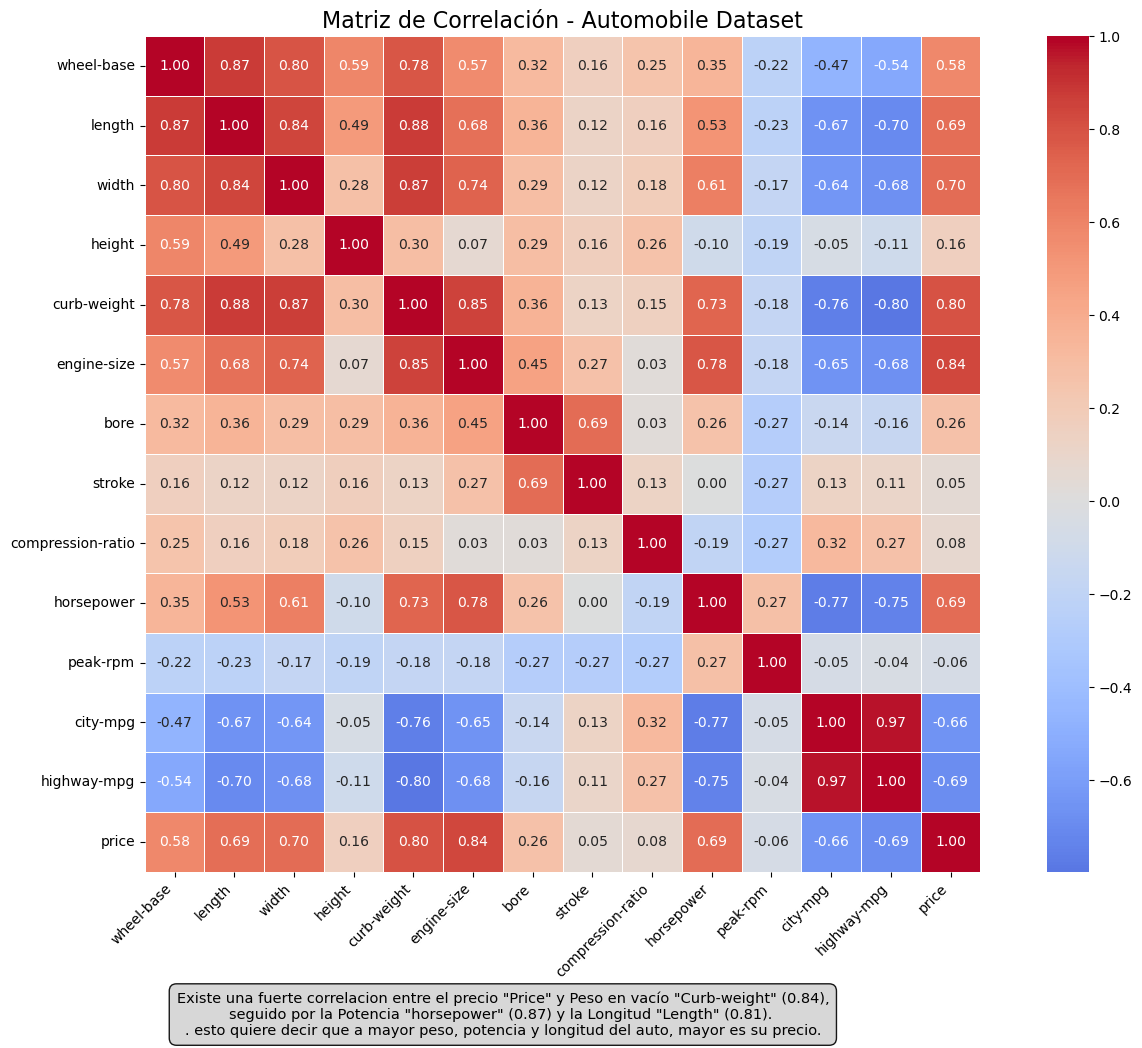

In [1502]:
columnas = ['wheel-base', 'length', 'width', 'height', 'curb-weight', 
                'engine-size', 'bore', 'stroke', 'compression-ratio', 
                'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']

# Eliminar filas con nulos para correlación
df_clean = df.dropna(subset=columnas)

# Matriz de correlación
correlation_matrix = df_clean[columnas].corr()

# Correlación con price
print(correlation_matrix['price'].sort_values(ascending=False).round(4))

df_clean = df.dropna(subset=columnas)

# Crear el gráfico
plt.figure(figsize=(14, 10))
corr_matrix = df_clean[columnas].corr()

sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0, 
            fmt='.2f', 
            linewidths=0.5, 
            square=True)

plt.title('Matriz de Correlación - Automobile Dataset', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.text(6, 16, 
         'Existe una fuerte correlacion entre el precio "Price" y Peso en vacío "Curb-weight" (0.84),\n' 
         'seguido por la Potencia "horsepower" (0.87) y la Longitud "Length" (0.81). \n'
         '. esto quiere decir que a mayor peso, potencia y longitud del auto, mayor es su precio.'
         ,
         ha='center', va='top', fontsize=10.5, 
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.9))


plt.show()


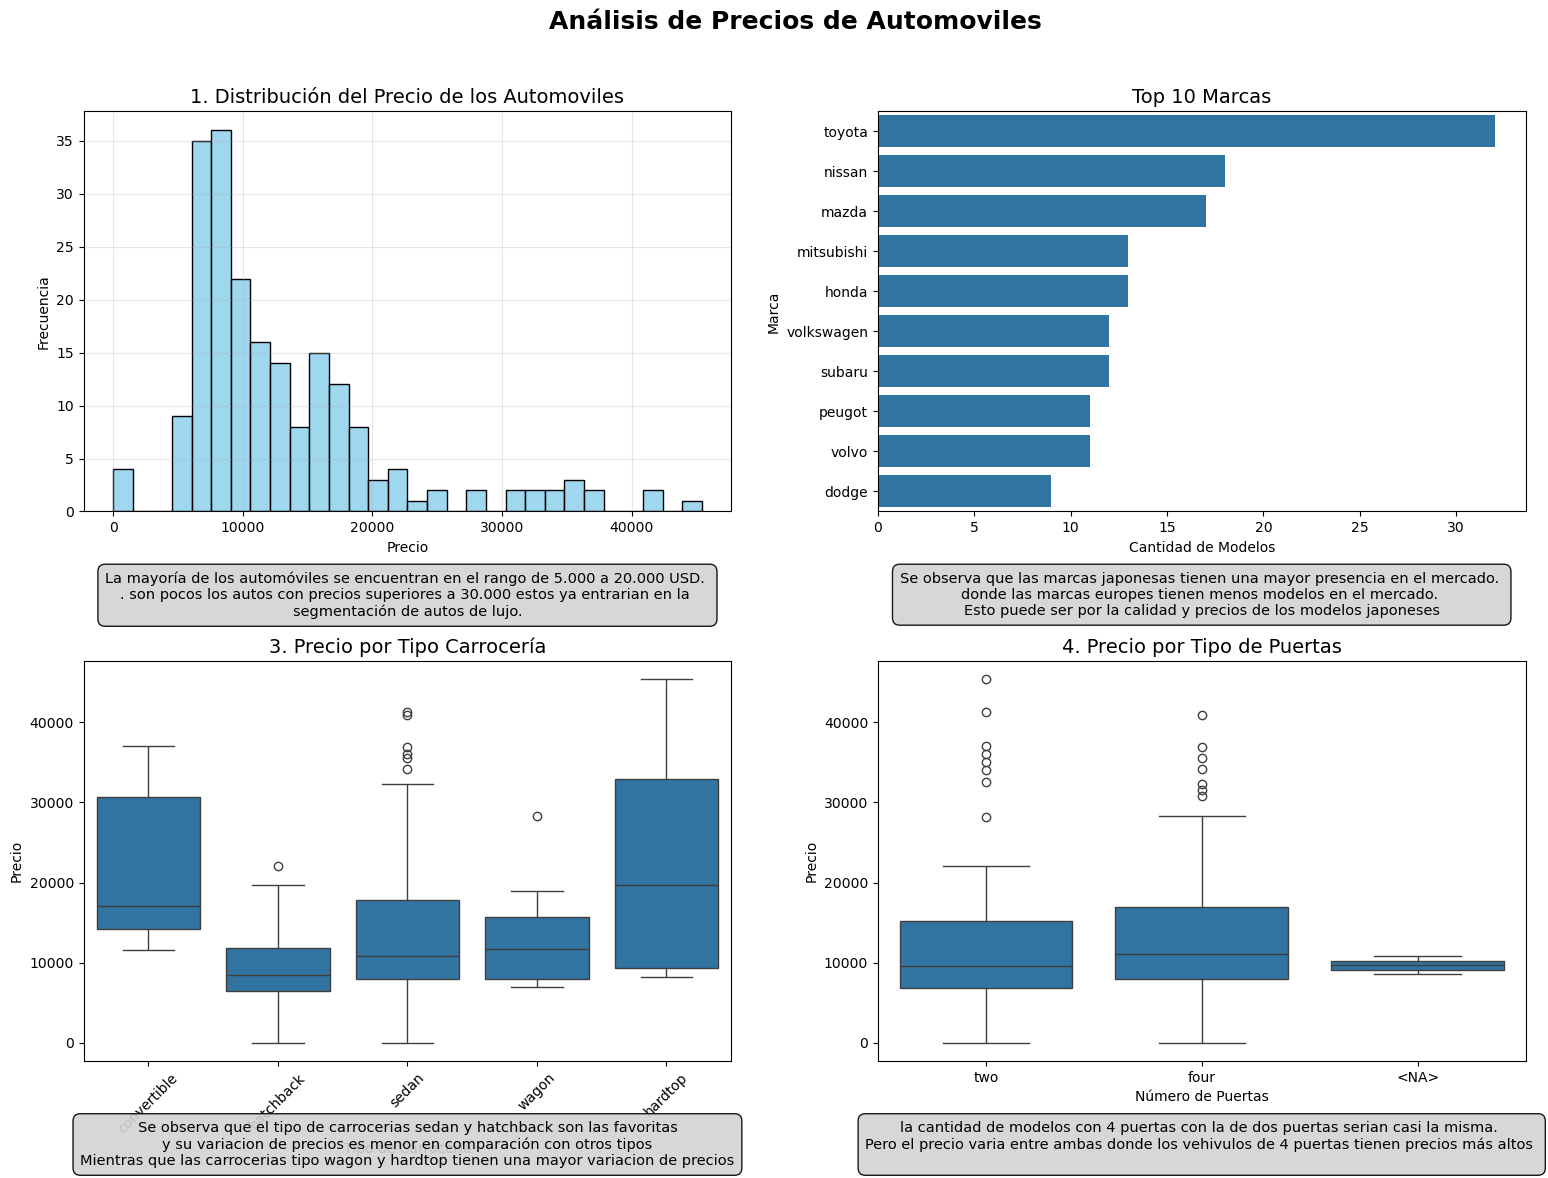

In [1503]:
# graficos


fig = plt.figure(figsize=(16, 12))
fig.suptitle('Análisis de Precios de Automoviles', fontsize=18, fontweight='bold')


# 1. Histplot - Distribución del Precio
ax1 = plt.subplot(2, 2, 1)
sns.histplot(data=df, x='price',bins=30, color='skyblue', edgecolor='black', alpha=0.8)
ax1.set_title('1. Distribución del Precio de los Automoviles', fontsize=14)
ax1.set_xlabel('Precio')
ax1.set_ylabel('Frecuencia')
ax1.grid(True, alpha=0.3)
# Interpretación dentro del gráfico 1
ax1.text(0.5, -0.15, 
         'La mayoría de los automóviles se encuentran en el rango de 5.000 a 20.000 USD. \n' 
         '. son pocos los autos con precios superiores a 30.000 estos ya entrarian en la \n' 
         'segmentación de autos de lujo.'
         '',
         transform=ax1.transAxes, ha='center', va='top', fontsize=10.5, 
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.9))

# Mejores Marcas de Autos
ax2 = plt.subplot(2, 2, 2)
top_makes = df['make'].value_counts().head(10)
sns.countplot(data=df, y='make', order=top_makes.index, ax=ax2)
ax2.set_title('Top 10 Marcas', fontsize=14)
ax2.set_xlabel('Cantidad de Modelos')
ax2.set_ylabel('Marca')

# Interpretación dentro del gráfico 2
ax2.text(0.5, -0.15, 
         'Se observa que las marcas japonesas tienen una mayor presencia en el mercado. \n' 
         'donde las marcas europes tienen menos modelos en el mercado. \n' 
         'Esto puede ser por la calidad y precios de los modelos japoneses'
         '',
         transform=ax2.transAxes, ha='center', va='top', fontsize=10.5, 
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.9))

# Precio por Carrocería
ax3 = plt.subplot(2, 2, 3)
sns.boxplot(data=df, x='body-style', y='price', ax=ax3)
ax3.set_title('3. Precio por Tipo Carrocería', fontsize=14)
ax3.set_xlabel('Tipo de Carrocería')
ax3.set_ylabel('Precio')
ax3.tick_params(axis='x', rotation=45)


# Interpretación dentro del gráfico 3
ax3.text(0.5, -0.15, 
         'Se observa que el tipo de carrocerias sedan y hatchback son las favoritas\n' 
         'y su variacion de precios es menor en comparación con otros tipos\n' 
         'Mientras que las carrocerias tipo wagon y hardtop tienen una mayor variacion de precios'
         '',
         transform=ax3.transAxes, ha='center', va='top', fontsize=10.5, 
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.9))

# 4. Boxplot - Precio por Tipo de Combustible
ax4 = plt.subplot(2, 2, 4)
sns.boxplot(data=df, x='num-of-doors', y='price', ax=ax4)
ax4.set_title('4. Precio por Tipo de Puertas', fontsize=14)
ax4.set_xlabel('Número de Puertas')
ax4.set_ylabel('Precio')

# Interpretación dentro del gráfico 4
ax4.text(0.5, -0.15, 
         'la cantidad de modelos con 4 puertas con la de dos puertas serian casi la misma. \n' 
         'Pero el precio varia entre ambas donde los vehivulos de 4 puertas tienen precios más altos \n' 
         ''
         '',
         transform=ax4.transAxes, ha='center', va='top', fontsize=10.5, 
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.9))




plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()



### Parte 2: Preparación de Datos

#### 2. Preprocesamiento:



- Selección de características importantes.


In [1504]:

columnas = ['wheel-base', 'length', 'width', 'height', 'curb-weight', 
                'engine-size', 'bore', 'stroke', 'compression-ratio', 
                'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']

# Eliminar filas con nulos para correlación
df_clean = df.dropna(subset=columnas)

# Matriz de correlación
correlacion = df_clean[columnas].corr()

# Correlación con price
print('\ncolumnas con correlacion a columna price: \n',correlacion['price'].sort_values(ascending=False).round(4))

# Filtrar características altamente correlacionadas con la variable objetivo mayor a 0.5
objetivo_corr = abs(correlacion['price'])
columnas_relevantes = objetivo_corr[objetivo_corr > 0.5]
print('\n columnas importantes con correlacion mayor a 0.5 : \n ',columnas_relevantes.index)


columnas con correlacion a columna price: 
 price                1.0000
engine-size          0.8381
curb-weight          0.7998
width                0.6957
horsepower           0.6913
length               0.6850
wheel-base           0.5788
bore                 0.2641
height               0.1584
compression-ratio    0.0780
stroke               0.0489
peak-rpm            -0.0553
city-mpg            -0.6600
highway-mpg         -0.6877
Name: price, dtype: float64

 columnas importantes con correlacion mayor a 0.5 : 
  Index(['wheel-base', 'length', 'width', 'curb-weight', 'engine-size',
       'horsepower', 'city-mpg', 'highway-mpg', 'price'],
      dtype='object')


- Transformación de variables categóricas.



In [1505]:
df_usar = df[['wheel-base', 'length', 'width', 'curb-weight', 'engine-size', 'bore',
       'horsepower', 'city-mpg', 'highway-mpg', 'price' , 'fuel-type']].copy()
# columnas retiradas ,'num-of-doors', 'body-style'
#display("dataframe a usar para el modelo : ", df_usar.head(10))

# Encoding de la categórica
df_cod = pd.get_dummies(df_usar, columns=['fuel-type'], drop_first=True, dtype=int)

display("dataframe con encoding de las variables categoricas : ", df_cod.head(10))
# print(f"Dataset despues de dummies: {df_cod.info()}")
# print(f"Dataset antes de dummies: {df_cod.shape}")

'dataframe con encoding de las variables categoricas : '

,wheel-base,length,width,curb-weight,engine-size,bore,horsepower,city-mpg,highway-mpg,price,fuel-type_gas
0,88.6,168.8,64.1,2548,130,3.47,111.0,21,27,13495.0,1
1,88.6,168.8,64.1,2548,130,3.47,111.0,21,27,16500.0,1
2,94.5,171.2,65.5,2823,152,2.68,154.0,19,26,16500.0,1
3,99.8,176.6,66.2,2337,109,3.19,102.0,24,30,13950.0,1
4,99.4,176.6,66.4,2824,136,3.19,115.0,18,22,17450.0,1
5,99.8,177.3,66.3,2507,136,3.19,110.0,19,25,15250.0,1
6,105.8,192.7,71.4,2844,136,3.19,110.0,19,25,17710.0,1
7,105.8,192.7,71.4,2954,136,3.19,110.0,19,25,18920.0,1
8,105.8,192.7,71.4,3086,131,3.13,140.0,17,20,23875.0,1
9,99.5,178.2,67.9,3053,131,3.13,160.0,16,22,0.0,1


- División del conjunto de datos en entrenamiento y prueba.


In [1506]:
# Features y target
X = df_cod.drop(columns=['price'])
y = df_cod['price']

# 3. Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

- Escalado de características.


In [1507]:
# Escalado de características
scaler = StandardScaler()
X_train_esc = scaler.fit_transform(X_train)
X_test_esc  = scaler.transform(X_test)

### Parte 3: Modelos de Regresión

#### 3. Regresión Lineal:



- Entrenamiento del modelo.


In [1508]:
#  Crear modelo y entrenar
modelo = LinearRegression()
modelo.fit(X_train_esc, y_train)
print('✅ Modelo entrenado')
print(f'Pendientes aprendidas: {modelo.coef_.round(2)}')
print(f'Intercepto:            {modelo.intercept_:,.2f}')

modelo

✅ Modelo entrenado
Pendientes aprendidas: [  183.13  1087.19  -253.29  -845.    5135.38  -874.59   182.16  -732.67
 -1618.02  -941.74]
Intercepto:            12,977.58


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


- Evaluación del rendimiento (MSE y R²).

In [1509]:
#  Predecir con el set de test
y_pred = modelo.predict(X_test_esc)

# Comparar real vs predicho (primeras 10)
comparacion = pd.DataFrame({
    'Real':     y_test.values[:10].round(0),
    'Predicho': y_pred[:10].round(0),
    'Error':    (y_test.values[:10] - y_pred[:10]).round(0)
})
comparacion

# metricas de evaluacion

mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("Evaluacion del modelo .")
print(f'MSE: {mse:,.0f} ()')
print(f'R²: {r2:.4f} ({r2*100:.1f}%)')

Evaluacion del modelo .
MSE: 22,949,038 ()
R²: 0.7344 (73.4%)


### 4. K-Nearest Neighbors (KNN):



- Entrenamiento del modelo.


In [1510]:
# Entrenamiento del modelo KNN
knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(X_train_esc, y_train)

# Realizar predicciones
y_pred = knn.predict(X_test_esc)


- Evaluación del rendimiento (MSE y R²).

MSE: 34,697,955 
R²: 0.5985 (59.8%)


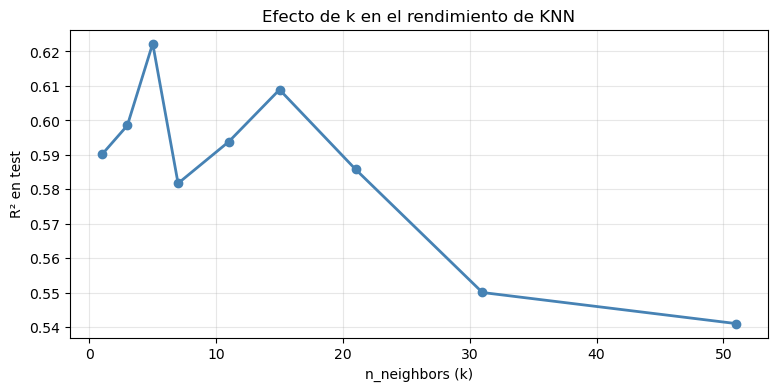

👉 Mejor k: 5 con R² = 0.6222
   Notar cómo k=1 suele ser peor (ruidoso) y k muy grande también baja (subajuste).


In [1511]:
# Evaluar el modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'MSE: {mse:,.0f} ')
print(f'R²: {r2:.4f} ({r2*100:.1f}%)')

# ¿Cómo cambia el R² con distintos k?
ks = [1, 3, 5, 7, 11, 15, 21, 31, 51]
scores = []

for k in ks:
    m = KNeighborsRegressor(n_neighbors=k).fit(X_train_esc, y_train)
    scores.append(m.score(X_test_esc, y_test))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ks, scores, marker='o', linewidth=2, color='steelblue')
ax.set_xlabel('n_neighbors (k)')
ax.set_ylabel('R² en test')
ax.set_title('Efecto de k en el rendimiento de KNN')
ax.grid(alpha=0.3)
plt.show()

mejor_k = ks[np.argmax(scores)]
print(f'👉 Mejor k: {mejor_k} con R² = {max(scores):.4f}')
print('   Notar cómo k=1 suele ser peor (ruidoso) y k muy grande también baja (subajuste).')

### 5. Árbol de Decisión:



- Entrenamiento del modelo.


In [1512]:
modelo_arbol = DecisionTreeRegressor(max_depth=5, random_state=42)
modelo_arbol.fit(X_train, y_train)

y_pred = modelo_arbol.predict(X_test)



- Evaluación del rendimiento (MSE y R²).

R²:   0.8215 (82.2%)
MSE  : 34,697,955.32


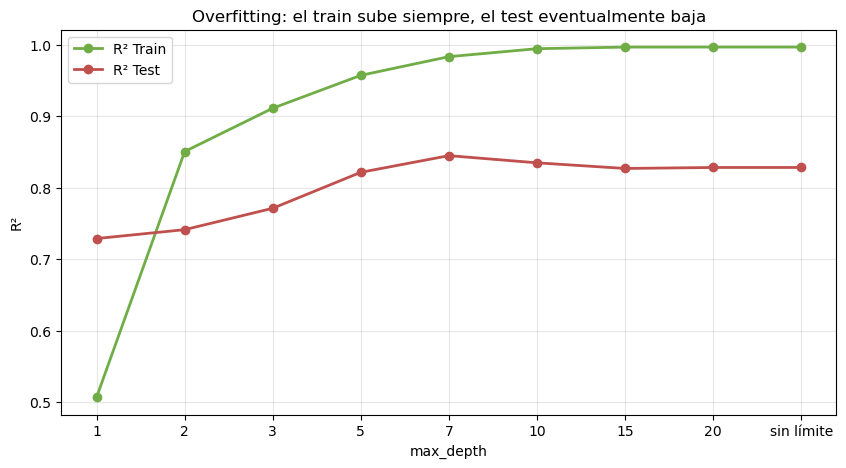

👉 Mira cómo el R² de train llega a casi 1.0 con árboles muy profundos.
   Pero el R² de test EMPIEZA A BAJAR — eso es overfitting.
   El truco está en encontrar el max_depth óptimo (típicamente 4-7).


In [1513]:
print(f'R²:   {r2_score(y_test, y_pred):.4f} ({r2_score(y_test, y_pred)*100:.1f}%)')
print(f"MSE  : {mse:,.2f}")
# Visualizar el árbol — esta es una de las grandes ventajas
# fig, ax = plt.subplots(figsize=(20, 8))
# plot_tree(modelo_arbol, 
#           feature_names=X.columns, 
#           filled=True, rounded=True, fontsize=9,
#           ax=ax)
# plt.title('Árbol de decisión para predecir MPG (profundidad máx = 4)', fontsize=14)
# plt.show()

#  El overfitting de los árboles — ver cómo cambia el R² según max_depth
depths = [1, 2, 3, 5, 7, 10, 15, 20, None]
scores_train, scores_test = [], []

for d in depths:
    m = DecisionTreeRegressor(max_depth=d, random_state=42).fit(X_train_esc, y_train)
    scores_train.append(m.score(X_train_esc, y_train))
    scores_test.append(m.score(X_test_esc, y_test))

fig, ax = plt.subplots(figsize=(10, 5))
x_labels = [str(d) if d is not None else 'sin límite' for d in depths]
ax.plot(x_labels, scores_train, marker='o', linewidth=2, color='#70AD47', label='R² Train')
ax.plot(x_labels, scores_test, marker='o', linewidth=2, color='#C0504D', label='R² Test')
ax.set_xlabel('max_depth')
ax.set_ylabel('R²')
ax.set_title('Overfitting: el train sube siempre, el test eventualmente baja')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print('👉 Mira cómo el R² de train llega a casi 1.0 con árboles muy profundos.')
print('   Pero el R² de test EMPIEZA A BAJAR — eso es overfitting.')
print('   El truco está en encontrar el max_depth óptimo (típicamente 4-7).')

## Parte 4: Benchmarking y Comparación de Modelos

### 6. Comparación de Modelos:



- Comparar los resultados de los tres modelos en términos de MSE y R².


In [1514]:
# Diccionario para almacenar resultados
resultados = {}

# Regresión Lineal
t_inicio = time.time()
lr = LinearRegression()
lr.fit(X_train, y_train)
t_fit = time.time() - t_inicio

t_inicio = time.time()
y_pred_lr = lr.predict(X_test)
t_pred = time.time() - t_inicio

resultados['Regresión Lineal '] = {
    'MSE': mean_squared_error(y_test, y_pred_lr),
    'R2': r2_score(y_test, y_pred_lr),
    'R2 (%)': f"{r2_score(y_test, y_pred_lr) * 100:.0f}%",
    'Tiempo fit (s)': round(t_fit, 2),
    'Tiempo pred (s)': round(t_pred, 3)
    }

# K-Nearest Neighbors (KNN)
t_inicio = time.time()
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
t_fit = time.time() - t_inicio

t_inicio = time.time()
y_pred_knn = knn.predict(X_test)
t_pred = time.time() - t_inicio

resultados['K-Nearest Neighbors (KNN)'] = {
    'MSE': mean_squared_error(y_test, y_pred_knn),
    'R2': r2_score(y_test, y_pred_knn),
    'R2 (%)' : f"{r2_score(y_test, y_pred_knn) * 100:.0f}%",
    'Tiempo fit (s)': round(t_fit, 2),
    'Tiempo pred (s)': round(t_pred, 3)
}

# Arbol de desicion
t_inicio = time.time()
dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
t_fit = time.time() - t_inicio

t_inicio = time.time()
y_pred_dt = dt.predict(X_test)

t_pred = time.time() - t_inicio


resultados['Arbol de desicion'] = {
    'MSE': mean_squared_error(y_test, y_pred_dt),
    'R2': r2_score(y_test, y_pred_dt),
    'R2 (%)' : f"{r2_score(y_test, y_pred_dt) * 100:.0f}%",
    'Tiempo fit (s)': round(t_fit, 2),
    'Tiempo pred (s)': round(t_pred, 3)
}

# ====================== 3. TABLA DE COMPARACIÓN ======================
comparacion = pd.DataFrame(resultados).T
comparacion = comparacion[['MSE',  'R2', 'R2 (%)', 'Tiempo fit (s)', 'Tiempo pred (s)']]



print("Comparacion de los 3 modelos : \n")

display(comparacion.round(3))



Comparacion de los 3 modelos : 



,MSE,R2,R2 (%),Tiempo fit (s),Tiempo pred (s)
Regresión Lineal,22949038.216335,0.734444,73%,0.0,0.001
K-Nearest Neighbors (KNN),36634287.961951,0.576084,58%,0.0,0.002
Arbol de desicion,15425145.981795,0.821507,82%,0.0,0.001


- Discusión sobre las diferencias en el rendimiento de los modelos.


##### Conclusiones :
##### 1. El modelo con mejor R² es la linea de regresion con un R2 del 82%  tiene un excelente rendimiento
##### 2. el modelo KNN   tiene un R² del 75%  es un buen modelo pero mejorable , y el arbol de decisiones también es un modelo razonables pero no tan buenos como la regresion lineal y KNN.

### 7. Interpretación de Resultados:




- 7.1 Analizar cuál de los modelos es más adecuado para el problema de predicción de precios de autos.


- R: por los resultados optenidos, el mejor modelo para predecir es la regrecion lineal con un 82% de R2, por que tiene  una relacion bastante lineal respecto al precio

- 7.2 Discutir posibles mejoras y próximos pasos, como el ajuste de hiperparámetros o el uso de técnicas avanzadas.

- R: posibles  mejoras: optimizar KNN y el orbol de desicion controlando el max_depth. revizar caractericticas y eliminar variables muy correlacionadas. Probar Modelos Más Avanzados como Random Forest Regressor.

### 8. Desafíos Adicionales:




- 8.1  Optimización de Modelos: Usar GridSearchCV para optimizar los hiperparámetros de KNN y el Árbol de Decisión.


In [1515]:
df_usar2 = df[['wheel-base', 'length', 'width', 'curb-weight', 'engine-size', 'bore',
       'horsepower', 'city-mpg', 'highway-mpg', 'price' , 'fuel-type','num-of-doors','body-style']].copy()
# columnas retiradas ,'num-of-doors', 'body-style'
#display("dataframe a usar para el modelo : ", df_usar.head(10))

# Encoding de la categórica , vamos a usar 3 columnas
df_cod2 = pd.get_dummies(df_usar2, columns=['fuel-type','num-of-doors','body-style'], drop_first=True, dtype=int)

display("dataframe con encoding de las variables categoricas : ", df_cod2.head(10))

X = df_cod2.drop(columns=['price'])
y = df_cod2['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

param_grid = {
    'n_estimators':     [50, 100, 200],
    'max_depth':        [5, 10, None],
    'min_samples_leaf': [1, 2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid, cv=5, scoring='r2', n_jobs=-1
).fit(X_train, y_train)

print(f'Combinaciones probadas: {3*3*3} × 5 folds = 135 entrenamientos')
print(f'Mejores hiperparámetros: {grid.best_params_}')
print(f'R² en test:              {grid.score(X_test, y_test):.4f}')


df = pd.get_dummies(df_usar2, columns=['fuel-type','num-of-doors','body-style'], drop_first=True, dtype=int)
X = df.drop(columns=['price']); y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelos = {
    'Lineal':  make_pipeline(StandardScaler(), LinearRegression()),
    'KNN':     make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=10)),
    'Árbol':   DecisionTreeRegressor(max_depth=10, random_state=42),
    'RF':      RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42),
    'GBR':     GradientBoostingRegressor(n_estimators=100, random_state=42)
}

scores = {}
for nombre, m in modelos.items():
    m.fit(X_train, y_train); scores[nombre] = r2_score(y_test, m.predict(X_test))
tabla = pd.Series(scores).sort_values(ascending=False)
print('Benchmark:'); print(tabla.round(4))

# Tuning del ganador (asumimos RF)
grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    {'n_estimators': [100, 200], 'max_depth': [10, 15, None]},
    cv=3, scoring='r2', n_jobs=-1
).fit(X_train, y_train)
print(f'\nMejor RF tuned: {grid.best_params_}')
print(f'R² sin tuning: {tabla["RF"]:.4f}')
print(f'R² con tuning: {grid.score(X_test, y_test):.4f}')


'dataframe con encoding de las variables categoricas : '

,wheel-base,length,width,curb-weight,engine-size,bore,horsepower,city-mpg,highway-mpg,price,fuel-type_gas,num-of-doors_four,num-of-doors_two,body-style_hardtop,body-style_hatchback,body-style_sedan,body-style_wagon
0,88.6,168.8,64.1,2548,130,3.47,111.0,21,27,13495.0,1,0,1,0,0,0,0
1,88.6,168.8,64.1,2548,130,3.47,111.0,21,27,16500.0,1,0,1,0,0,0,0
2,94.5,171.2,65.5,2823,152,2.68,154.0,19,26,16500.0,1,0,1,0,1,0,0
3,99.8,176.6,66.2,2337,109,3.19,102.0,24,30,13950.0,1,1,0,0,0,1,0
4,99.4,176.6,66.4,2824,136,3.19,115.0,18,22,17450.0,1,1,0,0,0,1,0
5,99.8,177.3,66.3,2507,136,3.19,110.0,19,25,15250.0,1,0,1,0,0,1,0
6,105.8,192.7,71.4,2844,136,3.19,110.0,19,25,17710.0,1,1,0,0,0,1,0
7,105.8,192.7,71.4,2954,136,3.19,110.0,19,25,18920.0,1,1,0,0,0,0,1
8,105.8,192.7,71.4,3086,131,3.13,140.0,17,20,23875.0,1,1,0,0,0,1,0
9,99.5,178.2,67.9,3053,131,3.13,160.0,16,22,0.0,1,0,1,0,1,0,0


Combinaciones probadas: 27 × 5 folds = 135 entrenamientos
Mejores hiperparámetros: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 50}
R² en test:              0.8169
Benchmark:
GBR       0.8398
Árbol     0.8357
RF        0.8211
Lineal    0.7020
KNN       0.6379
dtype: float64

Mejor RF tuned: {'max_depth': 10, 'n_estimators': 200}
R² sin tuning: 0.8211
R² con tuning: 0.8408


- 8.2 Feature Engineering: Crear nuevas características basadas en las existentes para mejorar el rendimiento del modelo.


In [1516]:

df_fe = df.copy()

# Nuevas características
df_fe['power_to_weight'] = df_fe['horsepower'] / df_fe['curb-weight'] * 1000  # Potencia por peso
df_fe['efficiency'] = (df_fe['city-mpg'] + df_fe['highway-mpg']) / 2          # Eficiencia promedio
df_fe['engine_efficiency'] = df_fe['horsepower'] / df_fe['engine-size']       # Eficiencia del motor

- 8.3 Validación Cruzada: Implementar validación cruzada para evaluar la estabilidad de los modelos.

In [1517]:

# Definir el modelo base + grilla de hiperparámetros a probar
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [10, 15, None]
}

# GridSearch con 3-fold CV (3 splits dentro del train) — total: 3×3×3 = 27 entrenamientos
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,                  # 3-fold CV
    scoring='r2',          # métrica a optimizar
    n_jobs=-1,             # paralelización
    verbose=1
)

print('Entrenando 27 combinaciones (3×3 hiperparámetros × 3 CV folds)...')
grid.fit(X_train, y_train)

print(f'\n🏆 Mejores hiperparámetros: {grid.best_params_}')
print(f'   Mejor R² (CV):           {grid.best_score_:.4f}')
print(f'   R² en test:              {grid.score(X_test, y_test):.4f}')

Entrenando 27 combinaciones (3×3 hiperparámetros × 3 CV folds)...
Fitting 3 folds for each of 9 candidates, totalling 27 fits

🏆 Mejores hiperparámetros: {'max_depth': 10, 'n_estimators': 200}
   Mejor R² (CV):           0.7689
   R² en test:              0.8408
